# Statistical Analysis of Air Pollutants in the City of Beijing
Below is a detailed analysis of a dataset obtained in the city of Beijing regarding the presence of air pollutants.
The dependent variables are PM2.5 and PM10, which are particles with a diameter of less than 2.5 micrometers and particles with a diameter of less than 10 micrometers, respectively. Meanwhile, the independent variables correspond to different chemical compounds found in the air (SO2, NO2, CO, and O3) and environmental factors such as temperature and wind speed. The R code used to perform the analysis is shown, along with the tables and charts generated from it. Below is the explanation of each column in the dataset as well as its contents.

### Dataset Attribute Information

<ul>
  <li><strong>No:</strong> row number</li>
  <li><strong>year:</strong> year</li>
  <li><strong>month:</strong> month</li>
  <li><strong>day:</strong> day</li>
  <li><strong>hour:</strong> hour</li>
  <li><strong>PM2.5:</strong> PM2.5 concentration (ug/m^3)</li>
  <li><strong>PM10:</strong> PM10 concentration (ug/m^3)</li>
  <li><strong>SO2:</strong> SO2 concentration (ug/m^3)</li>
  <li><strong>NO2:</strong> NO2 concentration (ug/m^3)</li>
  <li><strong>CO:</strong> CO concentration (ug/m^3)</li>
  <li><strong>O3:</strong> O3 concentration (ug/m^3)</li>
  <li><strong>TEMP:</strong> temperature (degrees Celsius)</li>
  <li><strong>PRES:</strong> barometric pressure (hPa)</li>
  <li><strong>DEWP:</strong> dew point temperature (degrees Celsius)</li>
  <li><strong>RAIN:</strong> precipitation (mm)</li>
  <li><strong>wd:</strong> wind direction</li>
  <li><strong>WSPM:</strong> wind speed (m/s)</li>
  <li><strong>station:</strong> monitoring station name</li>
</ul>

In [1]:
##Carga de librerias
library(jmv)
library(jmvcore)
library(ggplot2)

##Creación de Dataset a partir de archivo
data=read.csv("C:/Users/Adri/Documents/Tecnico analista de datos/Intro a Estadistica/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv")

data


Adjuntando el paquete: 'jmvcore'


The following objects are masked from 'package:base':

    endsWith, format, startsWith




No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,2013,3,1,0,9,9,3,17,300,89,-0.5,1024.5,-21.4,0,NNW,5.7,Dongsi
2,2013,3,1,1,4,4,3,16,300,88,-0.7,1025.1,-22.1,0,NW,3.9,Dongsi
3,2013,3,1,2,7,7,NA,17,300,60,-1.2,1025.3,-24.6,0,NNW,5.3,Dongsi
4,2013,3,1,3,3,3,5,18,NA,NA,-1.4,1026.2,-25.5,0,N,4.9,Dongsi
5,2013,3,1,4,3,3,7,NA,200,84,-1.9,1027.1,-24.5,0,NNW,3.2,Dongsi
6,2013,3,1,5,4,4,9,25,300,78,-2.4,1027.5,-21.3,0,NW,2.4,Dongsi
7,2013,3,1,6,5,5,10,29,400,67,-2.5,1028.2,-20.4,0,NW,2.2,Dongsi
8,2013,3,1,7,3,6,12,40,400,52,-1.4,1029.5,-20.4,0,NNW,3.0,Dongsi
9,2013,3,1,8,3,6,12,41,500,54,-0.3,1030.4,-21.2,0,NW,4.6,Dongsi


### Analysis of Central Tendency and Dispersion Measures
The descriptive statistical data is shown below, **separated by year**.

In [2]:
jmv::descriptives(
    formula = PM2.5 + PM10 + SO2 + NO2 + CO + O3 + TEMP + PRES  ~ year,
    data = data,
    mode = TRUE,
    variance = TRUE,
    sd = TRUE,
    skew = TRUE,
    kurt = TRUE)


 DESCRIPTIVES

 Descriptives                                                                                                               
 ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
                          year    PM2.5      PM10       SO2        NO2        CO          O3         TEMP         PRES      
 ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
   N                      2013       7201       7266       7166       7237        4677       7221       7344         7344   
                          2014       8663       8679       8671       7679        8657       8633       8760         8760   
                          2015       8633       8684       8686       8682        8685       8688       8758         8758   
                          2016       8431       8484       8480       8467        8466       8464       8777 

We can observe that the standard deviation is considerably high compared to the mean for all variables except atmospheric pressure, so the data is **not considered very representative**.

The analysis was performed by month, by day, and by hour to determine if the data would be more representative this way; however, as detailed below, the same behavior persists.

In [3]:
jmv::descriptives(
    formula = PM2.5 + PM10 + SO2 + NO2 + CO + O3 + TEMP + PRES ~ month,
    data = data,
    mode = TRUE,
    variance = TRUE,
    sd = TRUE,
    skew = TRUE,
    kurt = TRUE)


 DESCRIPTIVES

 Descriptives                                                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
                          month    PM2.5        PM10         SO2        NO2            CO          O3         TEMP          PRES         
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
   N                      1           2950         2955         2963         2662          2948       2946        2964          2964     
                          2           2653         2672         2648         2078          2634       2642        2711          2711     
                          3           2937         2937         2936         2935          2821       2919        2976          2976     
                  

In [4]:
jmv::descriptives(
    formula = PM2.5 + PM10 + SO2 + NO2 + CO + O3 + TEMP + PRES ~ day,
    data = data,
    mode = TRUE,
    variance = TRUE,
    sd = TRUE,
    skew = TRUE,
    kurt = TRUE)


 DESCRIPTIVES

 Descriptives                                                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
                          day    PM2.5        PM10         SO2        NO2           CO            O3         TEMP           PRES         
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
   N                      1         1139         1141         1141        1092          1051         1130         1152          1152     
                          2         1136         1146         1136        1099          1073         1146         1152          1152     
                          3         1143         1146         1144        1107          1072         1144         1152          1152     
                  

In [5]:
jmv::descriptives(
    formula = PM2.5 + PM10 + SO2 + NO2 + CO + O3 + TEMP + PRES ~ hour,
    data = data,
    mode = TRUE,
    variance = TRUE,
    sd = TRUE,
    skew = TRUE,
    kurt = TRUE)


 DESCRIPTIVES

 Descriptives                                                                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
                          hour    PM2.5        PM10         SO2        NO2          CO            O3           TEMP          PRES        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
   N                      0          1440         1445         1440       1402          1337         1442          1460         1460     
                          1          1438         1442         1439       1401          1340         1438          1461         1461     
                          2          1437         1442         1406       1400          1335         1439          1461         1461     
                  

### Charts

Below are the histograms corresponding to the previously analyzed variables.

Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."
Warning message:
"Removed 750 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 750 rows containing non-finite outside the scale range
(`stat_density()`)."
Warning message:
"Removed 553 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 553 rows containing non-finite outside the scale range
(`stat_density()`)."


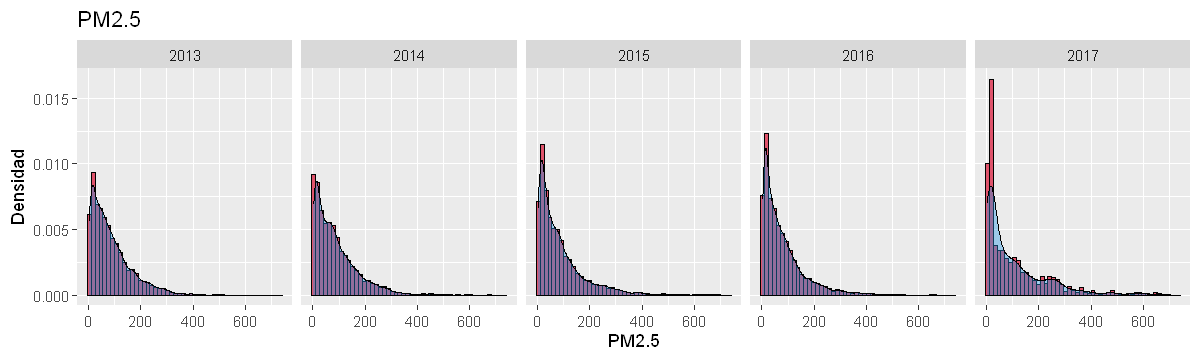

Warning message:
"Removed 663 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 663 rows containing non-finite outside the scale range
(`stat_density()`)."


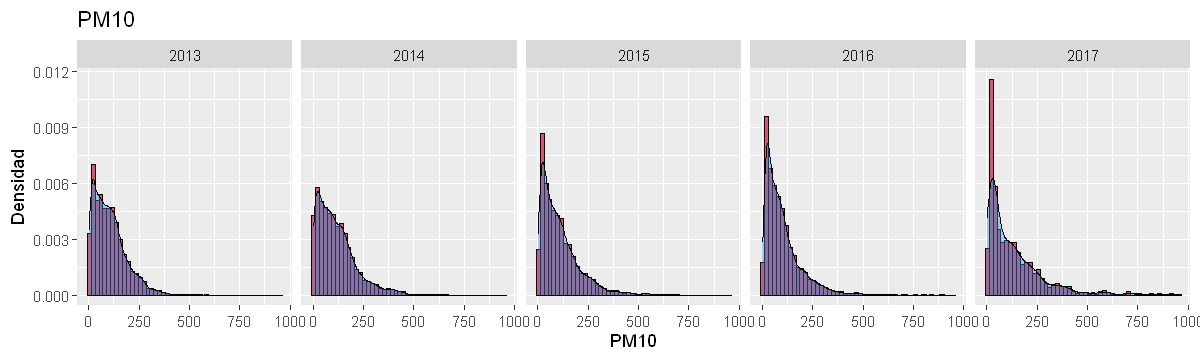

Warning message:
"Removed 1601 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 1601 rows containing non-finite outside the scale range
(`stat_density()`)."


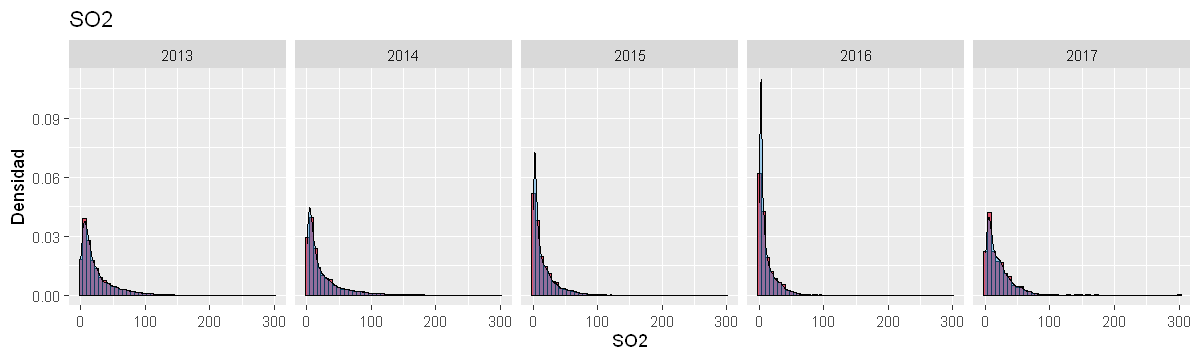

Warning message:
"Removed 3197 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 3197 rows containing non-finite outside the scale range
(`stat_density()`)."


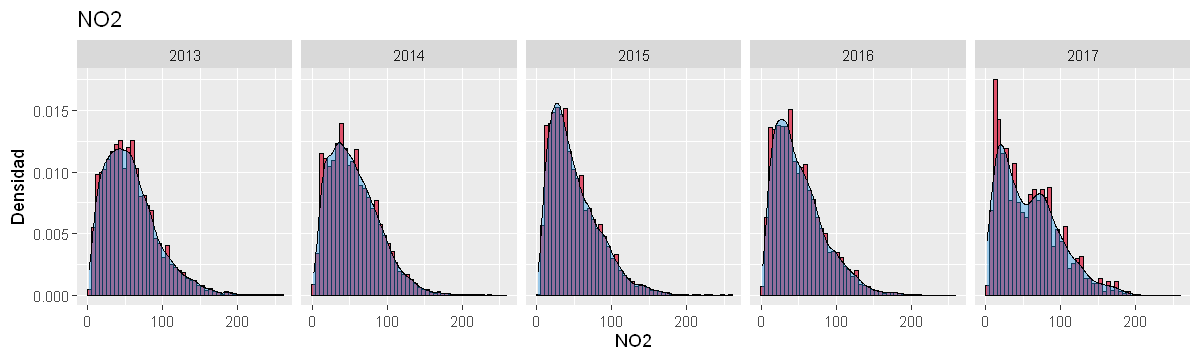

Warning message:
"Removed 664 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 664 rows containing non-finite outside the scale range
(`stat_density()`)."


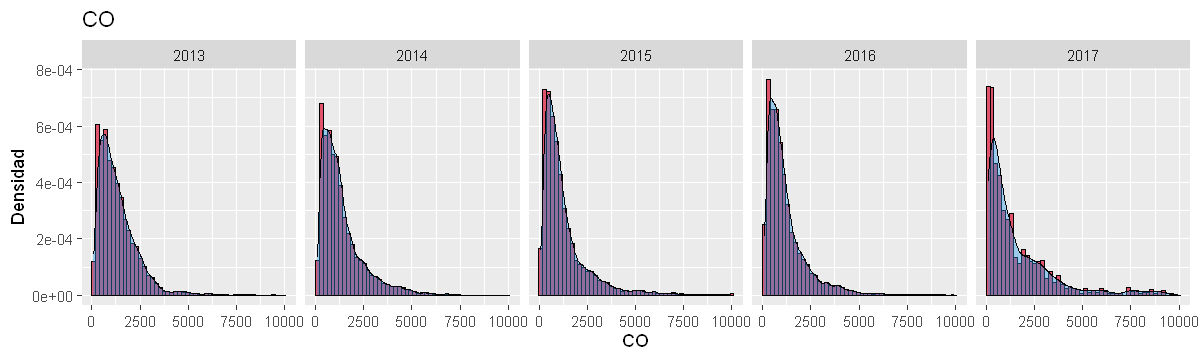

Warning message:
"Removed 20 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 20 rows containing non-finite outside the scale range
(`stat_density()`)."


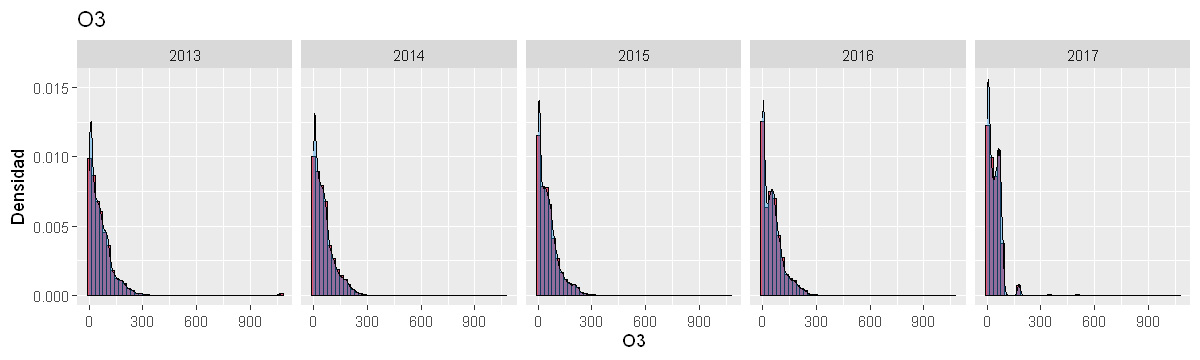

Warning message:
"Removed 20 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 20 rows containing non-finite outside the scale range
(`stat_density()`)."


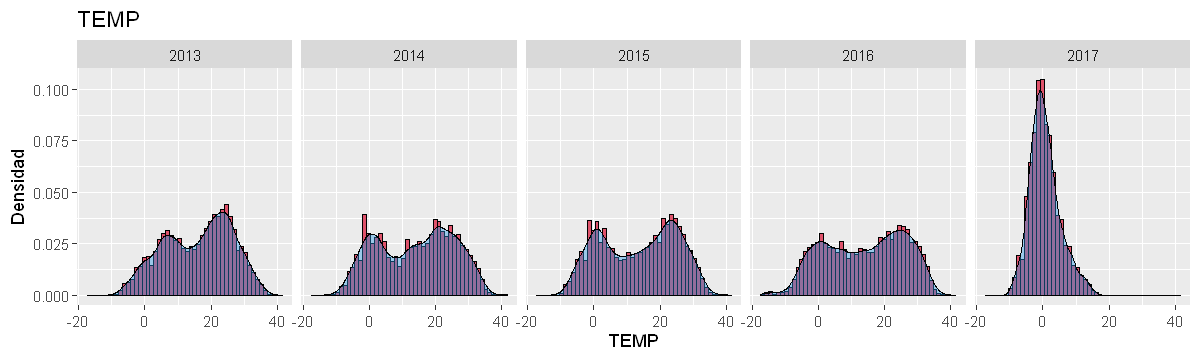

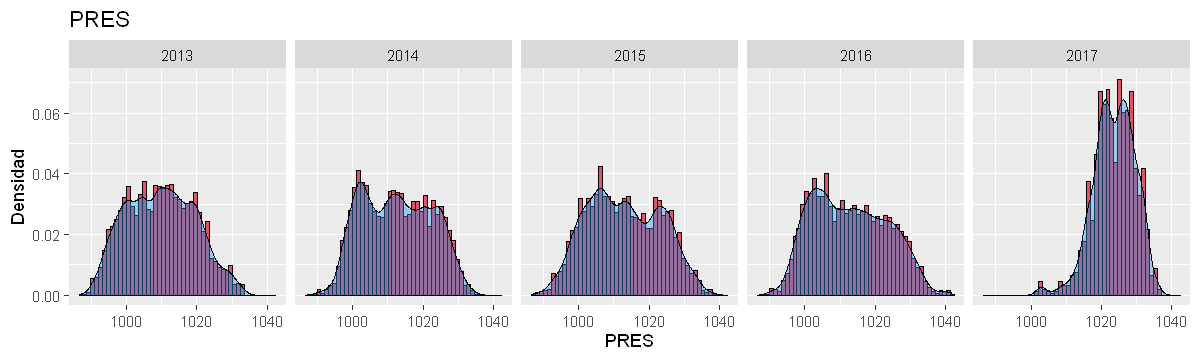

In [6]:
options(repr.plot.width = 10, repr.plot.height = 3)
for (x in 6:13){
    print(ggplot(data,aes(x=data[,x]))+
            geom_histogram(bins=50,aes(y=..density..),col=1,fill=10)+geom_density(fill=4,alpha=0.4)+
            facet_grid(.~year)+
            ggtitle(colnames(data)[x])+xlab(colnames(data)[x])+ylab("Densidad"))
    x=x+1
}


### Analysis of Variable Correlation and Linear Regression

Next, the Pearson linear correlation coefficient between all numerical variables is analyzed. **We can see that the PM2.5 and PM10 variables have a fairly high positive correlation with the amount of NO2 and CO**.

In [7]:

jmv::corrMatrix(
  data = data,
  vars = vars(PM2.5, TEMP, WSPM, RAIN, DEWP, PRES, O3, CO, NO2, SO2, PM10))


 CORRELATION MATRIX

 Correlation Matrix                                                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
                           PM2.5      TEMP       WSPM       RAIN       DEWP       PRES       O3         CO        NO2       SO2       PM10   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
   PM2.5    Pearson's r          —                                                                                                           
            df                   —                                                                                                           
            p-value              —                                                                                            

For the purpose of keeping the correlation matrix simplified, the matrix including only the dependent variables and the independent variables with the highest correlation (CO and NO2) is presented below. The linear regression process is also presented.


 CORRELATION MATRIX

 Correlation Matrix                                             
 ────────────────────────────────────────────────────────────── 
                           PM2.5     CO        NO2       PM10   
 ────────────────────────────────────────────────────────────── 
   PM2.5    Pearson's r         —                               
            df                  —                               
            p-value             —                               
                                                                
   CO       Pearson's r    0.8018         —                     
            df              31578         —                     
            p-value        < .001         —                     
                                                                
   NO2      Pearson's r    0.6933    0.7121         —           
            df              33176     30809         —           
            p-value        < .001    < .001         —           
   

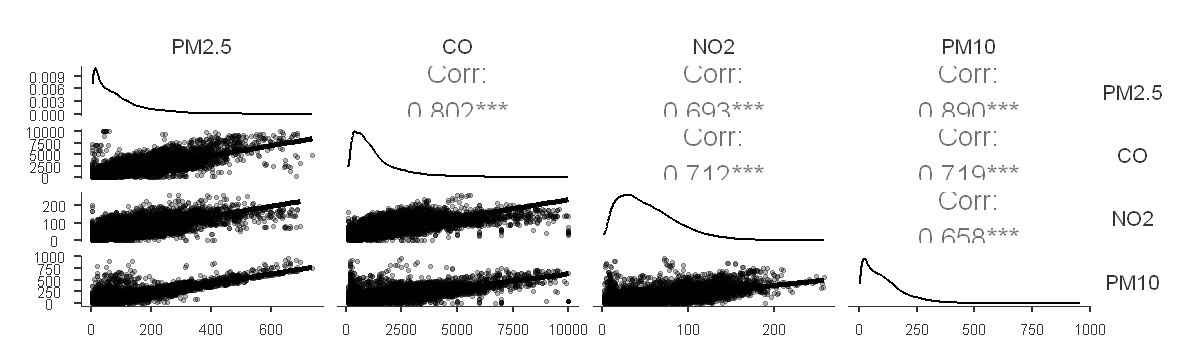

In [8]:
jmv::corrMatrix(
    data = data,
    vars = vars(PM2.5, CO, NO2, PM10),
    plots = TRUE,
    plotDens = TRUE,
    plotStats = TRUE)

In [9]:
jmv::linReg(
    data = data,
    dep = PM2.5,
    covs = vars(CO, NO2),
    blocks = list(
        list(
            "CO",
            "NO2")),
    refLevels = list())


 LINEAR REGRESSION

 Model Fit Measures            
 ───────────────────────────── 
   Model    R         R²       
 ───────────────────────────── 
       1    0.8215    0.6749   
 ───────────────────────────── 
   Note. Models estimated
   using sample size of
   N=30537


 MODEL SPECIFIC RESULTS

 MODEL 1

 Model Coefficients - PM2.5                                
 ───────────────────────────────────────────────────────── 
   Predictor    Estimate    SE          t         p        
 ───────────────────────────────────────────────────────── 
   Intercept    -8.19681     0.52070    -15.74    < .001   
   CO            0.04471    3.363e-4    132.95    < .001   
   NO2           0.63984     0.01168     54.79    < .001   
 ───────────────────────────────────────────────────────── 


In [10]:
jmv::linReg(
    data = data,
    dep = PM10,
    covs = vars(CO, NO2),
    blocks = list(
        list(
            "CO",
            "NO2")),
    refLevels = list())


 LINEAR REGRESSION

 Model Fit Measures            
 ───────────────────────────── 
   Model    R         R²       
 ───────────────────────────── 
       1    0.7482    0.5598   
 ───────────────────────────── 
   Note. Models estimated
   using sample size of
   N=30725


 MODEL SPECIFIC RESULTS

 MODEL 1

 Model Coefficients - PM10                                
 ──────────────────────────────────────────────────────── 
   Predictor    Estimate    SE          t        p        
 ──────────────────────────────────────────────────────── 
   Intercept     9.24749     0.69434    13.32    < .001   
   CO            0.04198    4.485e-4    93.59    < .001   
   NO2           0.86143     0.01553    55.45    < .001   
 ──────────────────────────────────────────────────────── 


### Conclusion

Although the correlation between the PM2.5, PM10, CO, and NO2 variables is fairly high, the high standard deviation of the data makes it non-representative. Therefore, it is not recommended to use these data to attempt to predict or determine the future behavior of the variables.